# Phase 12 — Explainability for PHM

## Why explainability matters in industrial maintenance

A PHM model may influence inspections, derating, spare-parts planning, or a decision to keep operating equipment. Engineers and maintainers need to understand whether a prediction is driven by plausible physical evidence, an operating-condition change, a sensor artifact, or data leakage. Explanations can support debugging, trust calibration, and investigation—but they do **not** prove causation, validate an HI, establish a failure mechanism, or make a bad model safe.

**Project readiness:** this IGBT project has no verified cohort-wide RUL target and no justified trained RUL model. Therefore, this notebook will not report importance for actual IGBT health/RUL. It uses an explicitly synthetic example to demonstrate model-dependent importance methods, then discusses how to apply them responsibly after target and baseline readiness.

## 1. Model interpretation: what question are we asking?

**Model interpretation** is the study of how a fitted model uses inputs to produce outputs, globally across a population or locally for one prediction. An explanation is conditional on the model, features, data distribution, and chosen baseline/reference. It answers questions such as "which inputs did this model rely on?"—not "which physical mechanism caused degradation?"

A useful workflow is:

1. Verify the target, train/test split, and model performance before explaining the model.
2. Define whether the question is global (overall behavior) or local (one device/time/prediction).
3. Explain on held-out, deployment-relevant data where possible; do not use the test set to tune the model after seeing explanations.
4. Check operating conditions, correlated predictors, device identity, time, source-file segments, and missingness as possible shortcuts.
5. Compare the explanation with engineering knowledge and counterexamples; treat disagreement as a prompt to investigate, not as proof that either model or expert is right.

Explanations are especially important in PHM because a model can score well by recognizing stress stage, test protocol, device identity, or measurement drift instead of degradation. A high feature-importance score is not evidence that changing that feature would change equipment health.

## 2. Feature importance

**Feature importance** is a family of summaries, not one unique quantity.

- **Impurity-based / built-in importance** (for example, a tree's `feature_importances_`) sums how much splits using a feature reduce the training loss/impurity. It is fast and global, but can favor continuous or high-cardinality features, spread credit unpredictably among correlated inputs, and reflect training fit rather than held-out utility.
- **Coefficient magnitude** in a linear model is interpretable only after considering units, scaling, collinearity, and interactions. Large coefficients do not necessarily imply high predictive importance.
- Importance is model- and dataset-dependent. It does not encode causal effect, physical criticality, monotonic health direction, or whether a feature is safe to use at decision time.

For IGBT data, a large importance for `source_file`, sample interval, or a gate-command feature would be a warning that the model may be learning acquisition/stress protocol. Collector-current features need special scrutiny because the dataset documentation reports current drift.

## 3. Permutation importance

**Permutation importance** asks how much a chosen evaluation score worsens when one feature's values are shuffled while the other columns are held fixed. If the score drops substantially, the fitted model relied on that feature for that evaluation distribution. Use a held-out set and the metric relevant to the deployment goal.

Important caveats:

- Shuffling breaks relationships between predictors. With correlated features, another feature may substitute for the permuted one, making each appear unimportant; or unrealistic combinations may distort the result.
- Standard row-wise shuffling destroys temporal/device structure. For sequences, use block-, group-, or conditional permutation designed for the question.
- Importance can be negative from sampling variability, meaning shuffled scores happened to improve; it is not "negative causal importance."
- It measures model reliance under a particular data distribution, not the effect of an intervention or a guaranteed physical mechanism.

The synthetic demonstration below intentionally includes two strongly correlated predictors. It trains a small Random Forest on invented data and calculates built-in and held-out permutation importances. These numbers illustrate method behavior only; they are not based on the IGBT dataset or a valid PHM target.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error

rng = np.random.default_rng(2026)
n_samples = 1200
degradation_signal = rng.normal(size=n_samples)
operating_context = rng.normal(size=n_samples)
redundant_degradation_sensor = degradation_signal + rng.normal(scale=0.12, size=n_samples)
irrelevant_noise = rng.normal(size=n_samples)
features = pd.DataFrame({
    "sensor_A_degradation_related": degradation_signal,
    "sensor_B_correlated_copy": redundant_degradation_sensor,
    "operating_context": operating_context,
    "irrelevant_noise": irrelevant_noise,
})
target = 2.5 * degradation_signal + 1.2 * operating_context + rng.normal(scale=0.5, size=n_samples)

split = 900
X_train, X_test = features.iloc[:split], features.iloc[split:]
y_train, y_test = target[:split], target[split:]
model = RandomForestRegressor(n_estimators=250, min_samples_leaf=3, random_state=2026, n_jobs=-1)
model.fit(X_train, y_train)
prediction = model.predict(X_test)
print(f"Synthetic held-out MAE: {mean_absolute_error(y_test, prediction):.3f} (invented target units)")

permutation = permutation_importance(
    model, X_test, y_test, scoring="neg_mean_absolute_error",
    n_repeats=30, random_state=2026, n_jobs=-1,
)
importance = pd.DataFrame({
    "feature": features.columns,
    "impurity_importance": model.feature_importances_,
    "permutation_MAE_increase": permutation.importances_mean,
    "permutation_repeat_std": permutation.importances_std,
}).sort_values("permutation_MAE_increase", ascending=False)
importance

Synthetic held-out MAE: 0.490 (invented target units)


,feature,impurity_importance,permutation_MAE_increase,permutation_repeat_std
0,sensor_A_degradation_related,0.451608,1.262655,0.057170
2,operating_context,0.157912,0.938249,0.050527
1,sensor_B_correlated_copy,0.385932,0.557207,0.034601
3,irrelevant_noise,0.004548,0.001739,0.002268


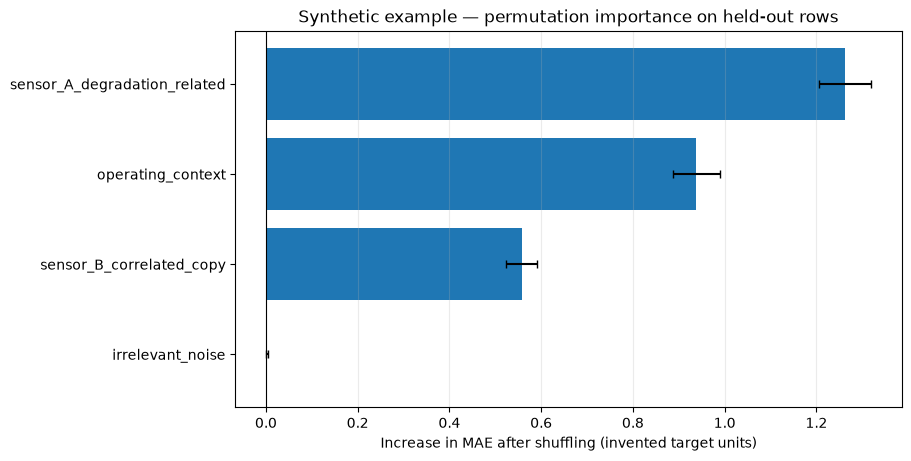

sensor_A / sensor_B correlation: 0.9922894024633188
Importance is predictive reliance in this synthetic test set—not causal effect or physical relevance.


In [2]:
plot_data = importance.sort_values("permutation_MAE_increase")
fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
ax.barh(
    plot_data["feature"], plot_data["permutation_MAE_increase"],
    xerr=plot_data["permutation_repeat_std"], capsize=3,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Synthetic example — permutation importance on held-out rows",
       xlabel="Increase in MAE after shuffling (invented target units)")
ax.grid(axis="x", alpha=0.25)
plt.show()
print("sensor_A / sensor_B correlation:", X_test["sensor_A_degradation_related"].corr(
    X_test["sensor_B_correlated_copy"]
))
print("Importance is predictive reliance in this synthetic test set—not causal effect or physical relevance.")

Because sensor A and sensor B carry nearly the same signal, shuffling either one can leave the model access to the other. Their individual permutation importances may therefore understate the value of the shared information. Grouped permutation (shuffle both together) or a carefully chosen conditional method can answer a different question. This is also why importance ranks for correlated electrical descriptors should not be interpreted as a definitive ordering of degradation mechanisms.

## 4. SHAP: additive feature attributions

**SHAP** (SHapley Additive exPlanations) assigns additive contribution values to features relative to a reference/background prediction. For one explained case, the usual additive form is:

$$f(x) = \mathbb{E}[f(X)] + \sum_{j=1}^{F} \phi_j$$

where the base value is the model's expected output under a chosen background distribution and `phi_j` is the attribution assigned to feature `j` for this case. A positive contribution moves the model output above the base value; a negative contribution moves it below. Aggregating absolute attributions over cases can give a global summary, while a per-case force/waterfall view explains one model output.

SHAP's Shapley-value foundation has attractive attribution properties, but practical explainers approximate conditional expectations and must choose how to handle feature dependence. With correlated predictors, attribution can be shared or assigned differently depending on the background and dependence assumptions. TreeSHAP can be efficient for tree models; KernelSHAP is more model-agnostic but may be expensive. Always identify the output scale (e.g., hours, log-odds), background population, explainer, and whether values are local or aggregated.

A SHAP explanation answers how the fitted model decomposed a prediction relative to a reference—not what physically caused an IGBT to degrade. Plausible attributions can still arise from leakage, confounding, poor calibration, or an invalid RUL target.

## 5. Applying explanation methods to PHM responsibly

Once a valid, device-aware baseline exists:

1. Explain held-out devices/runs, not only training rows; quantify variation in importance across held-out units.
2. Compare impurity importance, grouped/permutation importance, and local SHAP explanations. Disagreement is diagnostic information.
3. Inspect explanations by operating stage, device, prediction horizon, and error magnitude. Check whether importance shifts under distribution change.
4. Review correlated feature groups together (for example, RMS, absolute peak, and peak-to-peak from one channel); single-feature rankings can mislead.
5. Check for time, file, device-ID, missingness, sampling-rate, and stress-setting shortcuts. If these dominate, revisit target design and validation.
6. Ask engineers whether local contributions make sense under known physics, then test hypotheses with controlled experiments or independent measurements.

For maintenance decisions, explain both the prediction and its uncertainty, state model limitations, and define a safe escalation path. Explainability supports human review; it is not a substitute for validation, traceable evidence, or engineering judgment.

## Phase 12 learning check

1. What does impurity-based feature importance measure, and why can it be biased?
2. What question does permutation importance answer? Why can correlated features mask one another?
3. How does SHAP explain an individual model output relative to a baseline?
4. Why are feature importance and SHAP not causal explanations?
5. What protocol or acquisition shortcuts might be important in the IGBT data?
6. Why does a plausible explanation not make an invalid RUL model trustworthy?

**Readiness decision:** this notebook reports importance only for invented data. The IGBT project needs a justified target and trained, leakage-safe baseline before model explanations can be interpreted as anything about equipment health or maintenance.